# Loan portfolio analysis

__Objective__
In January 2023, a bank is considering purchasing a portfolio of loans from another bank and has the option to buy all, some, or none of the portfolio. The aim of the analysis is to support the decision on which part of the portfolio to acquire, using leverage (loan size / EBITDA 2022) and the 2023 EBITDA growth forecast.

Leverage levels follow the Credit Team's rules of thumb: __High__ > 3x, __Mid__ 2x to 3x, __Low__ < 2x.

__Data cleaning__
- __Missing values__: 3 clients with missing or invalid metrics (PG964431, DS757939, AD254332) were excluded. PG964431 has a typo in the growth forecast ("0.a") and could be added back once the value is confirmed.
- __Duplicates__: 3 complete duplicates (DN742019, MJ690532, UD379577) were removed.
- __Data errors__: 5 loans have values that are not plausible and were removed until they can be corrected:
    - JY724839: EBITDA of 0 (leverage cannot be calculated)
    - BH868720: loan size of £41bn (480x leverage), likely a typo
    - OK197176: growth forecast of 9,999,999 (placeholder value)
    - MS704080: growth forecast of 600%, likely 6% entered incorrectly
    - CE750358: EBITDA of £4,680 and loan size of £9,828, likely entered in thousands
- __Outliers kept for investigation__:
    - FE732470 (manufacturing): leverage of 9.6x is extreme but plausible, so it is kept in the analysis as a high risk loan
    - ZZ513736 (green energy): EBITDA of £4.7bn is ~100x the sector median and the loan is £3.8bn. Values look consistent (0.8x leverage) but need to be verified before any decision

__Analysis results__
- __Portfolio characteristics__: The portfolio consists of 89 loans from four sectors (green energy, real estate, manufacturing, infrastructure) with a total value of £21.1bn. Manufacturing accounts for 36% of loan value, followed by infrastructure with 28%. 54% of loans are high leverage and 39% have negative growth forecasts.
- __Concentration__: One green energy client (ZZ513736) accounts for 18% of total loan value and 51% of total EBITDA. It makes the aggregate portfolio look much better than it is: aggregate leverage is 2.25x and growth 8.8% with this client, but __3.7x and 1.4% without it__.
- __Loan size distribution__: Green energy and real estate loans are smaller deals (median loan size of £54m and £129m), while infrastructure and manufacturing loans have a median above £200m.
- __Risk and growth assessment__: Green energy (median leverage 1.4x, growth 16%) and real estate (2.6x, 4%) are the most attractive sectors. Manufacturing (5.0x, -6%) and infrastructure (4.1x, 1%) combine high leverage with low or negative growth.
- __Forward leverage (2023)__: Using forecast 2023 EBITDA, green energy and real estate de-lever further, while manufacturing leverage rises (median 5.4x). 10 loans change leverage level. Excluding ZZ513736, the portfolio's aggregate leverage stays at 3.7x, so it does not grow out of its debt.

__Recommendations__
- Do not acquire manufacturing loans (no loan below 2x leverage, and all forecasts are flat or negative), and only consider the few infrastructure loans with leverage of 3x or below and positive growth.
- __Option 1__: low leverage loans (< 2x) with positive growth: 19 loans, £5.2bn, 0.92x leverage, 14.8% growth.
- __Option 2__: low and mid leverage loans (≤ 3x) with positive growth: 35 loans, £7.4bn, 1.13x leverage, 13.6% growth.
- __Both options depend heavily on ZZ513736__ (73% of Option 1 and 51% of Option 2 by value). Without it, Option 2 is 34 loans, £3.6bn, 2.0x leverage (1.86x forecast for 2023), 7.4% growth, and stays below 2x even if growth is 5 points lower than forecast. Recommend treating ZZ513736 as a separate decision after verifying its financials and checking it against single-name concentration limits.
- __Recommended approach__: Option 2 excluding ZZ513736 as the core purchase (diversified, all loans ≤ 3x with positive growth). Consider adding 2 real estate loans that are forecast to fall to 3x or below in 2023. Add ZZ513736 only if its financials are confirmed.

__Limitations__: No information on pricing, interest rates, maturity or collateral, so this is a risk screen, not a valuation.

## 1 Preparation for analysis
### 1.1 Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
# Colours used for sectors in all charts
graph_palette = {
    'green energy': 'lightgreen',
    'real estate': 'darkgrey',
    'infrastructure': 'wheat',
    'manufacturing': 'darksalmon'
}
sector_order = ['green energy', 'real estate', 'infrastructure', 'manufacturing']

# Format axis ticks in millions
def millions_formatter(x, pos):
    return f'{x / 1000000:.0f}M'

### 1.2 Import data set and initial investigation

In [3]:
# Read in csv file and run initial checks
portfolio = pd.read_csv('data/loan_portfolio.csv')

print(portfolio.shape)
print(portfolio.dtypes)
portfolio.head()

(100, 5)
borrower_id                 str
ebitda_2022             float64
growth_forecast_2023        str
loan_size                   str
sector                      str
dtype: object


,borrower_id,ebitda_2022,growth_forecast_2023,loan_size,sector
0,ZZ513736,4.740000e+09,0.16,3792000000,green energy
1,ZR624574,7.230000e+07,0.19,97605000,green energy
2,ZM620886,3.470000e+07,0.03,229020000,infrastructure
3,ZG676447,8.630000e+07,0.03,207120000,infrastructure
4,ZA701561,1.390000e+07,-0.07,83400000,manufacturing


In [4]:
# Change float format
pd.set_option('display.float_format', lambda x: '%.2f' % x)

### 1.3 Data conversion
growth_forecast_2023 and loan_size are read in as text, so some values can't be converted to numbers. Check which ones before converting.

In [5]:
# Values that can't be converted to numbers
for col in ['growth_forecast_2023', 'loan_size']:
    not_numeric = pd.to_numeric(portfolio[col], errors='coerce').isna()
    print(portfolio.loc[not_numeric, ['borrower_id', col]])

   borrower_id growth_forecast_2023
31    PG964431                  0.a
   borrower_id loan_size
98    AD254332          


In [6]:
# Convert (invalid values become NaN)
portfolio['growth_forecast_2023'] = pd.to_numeric(portfolio['growth_forecast_2023'], errors='coerce')
portfolio['loan_size'] = pd.to_numeric(portfolio['loan_size'], errors='coerce')

print(portfolio.dtypes)
portfolio.describe()

borrower_id                 str
ebitda_2022             float64
growth_forecast_2023    float64
loan_size               float64
sector                      str
dtype: object


,ebitda_2022,growth_forecast_2023,loan_size
count,99.00,99.00,99.00
mean,100456612.93,101010.17,645808180.08
std,471746098.73,1005037.71,4125001005.18
min,0.00,-0.09,9828.00
25%,29050000.00,-0.04,85950000.00
50%,55000000.00,0.02,150300000.00
75%,73450000.00,0.06,267690000.00
max,4740000000.00,9999999.00,41088000000.00


### 1.4 Data quality checks

In [7]:
# Show missing values
missing_values = portfolio.isnull().any(axis=1)
portfolio[missing_values]

,borrower_id,ebitda_2022,growth_forecast_2023,loan_size,sector
31,PG964431,99700000.00,NaN,797600000.00,manufacturing
78,DS757939,NaN,-0.08,109560000.00,manufacturing
98,AD254332,88900000.00,0.08,NaN,real estate


In [8]:
# Removing entries with missing values
# PG964431 has a typo in growth forecast ('0.a'), could be added back once the value is confirmed
portfolio = portfolio.dropna()
print(portfolio.isna().sum())

borrower_id             0
ebitda_2022             0
growth_forecast_2023    0
loan_size               0
sector                  0
dtype: int64


In [9]:
# Number of duplicated borrower IDs
print(portfolio['borrower_id'].duplicated().sum())

duplicates = portfolio.duplicated(subset=['borrower_id'], keep=False)
portfolio[duplicates].sort_values(by='borrower_id')

3


,borrower_id,ebitda_2022,growth_forecast_2023,loan_size,sector
81,DN742019,28300000.00,0.10,93390000.00,real estate
82,DN742019,28300000.00,0.10,93390000.00,real estate
47,MJ690532,55000000.00,0.16,121000000.00,green energy
48,MJ690532,55000000.00,0.16,121000000.00,green energy
17,UD379577,79000000.00,-0.04,363400000.00,manufacturing
18,UD379577,79000000.00,-0.04,363400000.00,manufacturing


In [10]:
# Complete duplicates, delete one instance
portfolio = portfolio.drop_duplicates()
print(len(portfolio))

94


In [11]:
# Check categories in sector and naming conventions
print(portfolio['sector'].value_counts())

sector
infrastructure    28
manufacturing     28
real estate       23
green energy      14
green energies     1
Name: count, dtype: int64


In [12]:
# Standardising green energy category name
portfolio['sector'] = portfolio['sector'].replace('green energies', 'green energy')
print(portfolio['sector'].value_counts())

sector
infrastructure    28
manufacturing     28
real estate       23
green energy      15
Name: count, dtype: int64


### 1.5 Calculating leverage ratio and leverage level

In [13]:
# Calculating leverage ratio
portfolio['leverage_ratio'] = portfolio['loan_size'] / portfolio['ebitda_2022']

# Leverage levels based on Credit Team rules of thumb: >3x high, 2-3x mid, <2x low
leverage_categories = [
    (portfolio['leverage_ratio'] > 3.0),
    (portfolio['leverage_ratio'] >= 2.0),
    (portfolio['leverage_ratio'] < 2.0)
]
leverage_levels = ['High leverage', 'Mid-leverage', 'Low leverage']

portfolio['leverage_levels'] = np.select(leverage_categories, leverage_levels, default='')

### 1.6 Outlier checks
Using IQR to flag outliers, then reviewing each flagged loan to decide if it is a data error (remove) or a genuine extreme value (keep and investigate).

In [14]:
# Leverage is infinite for EBITDA = 0, replaced with NaN for the summary
portfolio.replace(np.inf, np.nan).describe()

,ebitda_2022,growth_forecast_2023,loan_size,leverage_ratio
count,94.00,94.00,94.00,93.00
mean,102067071.06,106383.05,664362338.60,8.71
std,484171370.76,1031421.13,4233162416.12,49.44
min,0.00,-0.09,9828.00,0.60
25%,28875000.00,-0.04,84705000.00,2.05
50%,53900000.00,0.01,156342500.00,3.30
75%,72825000.00,0.06,253560000.00,4.80
max,4740000000.00,9999999.00,41088000000.00,480.00


In [15]:
# Function to calculate IQR thresholds
def iqr_thresholds(series):
    q25 = series.quantile(0.25)
    q75 = series.quantile(0.75)
    iqr = q75 - q25
    return q25 - 1.5 * iqr, q75 + 1.5 * iqr

growth_lower, growth_upper = iqr_thresholds(portfolio['growth_forecast_2023'])
leverage_lower, leverage_upper = iqr_thresholds(portfolio['leverage_ratio'].replace(np.inf, np.nan))

print(f'Growth thresholds: {growth_lower:.1%} to {growth_upper:.1%}')
print(f'Leverage thresholds: {max(0, leverage_lower):.2f}x to {leverage_upper:.2f}x')

Growth thresholds: -18.6% to 20.4%
Leverage thresholds: 0.00x to 8.93x


In [16]:
# Loans flagged as outliers
outlier_flag = (
    (portfolio['growth_forecast_2023'] < growth_lower) | (portfolio['growth_forecast_2023'] > growth_upper) |
    (portfolio['leverage_ratio'] > leverage_upper)
)
portfolio[outlier_flag]

,borrower_id,ebitda_2022,growth_forecast_2023,loan_size,sector,leverage_ratio,leverage_levels
34,OK197176,92000000.00,9999999.00,55200000.00,green energy,0.60,Low leverage
43,MS704080,44700000.00,6.00,120690000.00,real estate,2.70,Mid-leverage
56,JY724839,0.00,0.04,106920000.00,real estate,inf,High leverage
72,FE732470,18100000.00,0.00,173760000.00,manufacturing,9.60,High leverage
92,BH868720,85600000.00,-0.02,41088000000.00,manufacturing,480.00,High leverage


Reviewing the flagged loans:
- JY724839: EBITDA of 0, leverage can't be calculated, **data error**
- BH868720: loan size of £41bn vs EBITDA of £86m (480x), likely a typo, **data error**
- OK197176: growth forecast of 9,999,999, placeholder value, **data error**
- MS704080: growth forecast of 6.00 (600%), likely 6% entered incorrectly, **data error**
- FE732470: leverage of 9.6x is very high but possible for a manufacturing business, **kept** as a high risk loan

Also checking the smallest and largest values, as these are not caught by the IQR check on leverage:

In [17]:
portfolio.sort_values('ebitda_2022').head(3)

,borrower_id,ebitda_2022,growth_forecast_2023,loan_size,sector,leverage_ratio,leverage_levels
56,JY724839,0.00,0.04,106920000.00,real estate,inf,High leverage
88,CE750358,4680.00,0.08,9828.00,real estate,2.10,Mid-leverage
4,ZA701561,13900000.00,-0.07,83400000.00,manufacturing,6.00,High leverage


In [18]:
portfolio.sort_values('ebitda_2022', ascending=False).head(3)

,borrower_id,ebitda_2022,growth_forecast_2023,loan_size,sector,leverage_ratio,leverage_levels
0,ZZ513736,4740000000.00,0.16,3792000000.00,green energy,0.80,Low leverage
76,EQ261295,97600000.00,-0.07,585600000.00,manufacturing,6.00,High leverage
77,DU496818,97600000.00,-0.01,395280000.00,infrastructure,4.05,High leverage


- CE750358: EBITDA of £4,680 and loan of £9,828 when all other loans are in the millions, likely entered in thousands, **data error**
- ZZ513736: EBITDA of £4.7bn (~100x the sector median) and loan of £3.8bn. The leverage (0.8x) is in line with the sector so the values could be correct, **kept** but needs to be verified

In [19]:
data_errors = ['JY724839', 'BH868720', 'OK197176', 'MS704080', 'CE750358']

portfolio_clean = portfolio[~portfolio['borrower_id'].isin(data_errors)].copy()
print(len(portfolio_clean))

89


# 2 Loan portfolio analysis

In [20]:
# High level portfolio overview
portfolio_clean.describe()

,ebitda_2022,growth_forecast_2023,loan_size,leverage_ratio
count,89.00,89.00,89.00,89.00
mean,105303370.79,0.02,236845393.26,3.65
std,497445841.60,0.08,409724321.62,2.00
min,13900000.00,-0.09,17100000.00,0.70
25%,29400000.00,-0.04,85860000.00,2.05
50%,55000000.00,0.01,163680000.00,3.40
75%,72300000.00,0.05,253980000.00,4.80
max,4740000000.00,0.20,3792000000.00,9.60


In [21]:
# Function for aggregate KPIs: total loan size, aggregate leverage and EBITDA-weighted growth
def portfolio_kpis(df):
    ebitda = df['ebitda_2022'].sum()
    return pd.Series({
        'loans': len(df),
        'loan_size_bn': df['loan_size'].sum() / 1e9,
        'leverage_ratio': df['loan_size'].sum() / ebitda,
        'leverage_2023': df['loan_size'].sum() / (df['ebitda_2022'] * (1 + df['growth_forecast_2023'])).sum(),
        'growth_forecast_2023': (df['ebitda_2022'] * df['growth_forecast_2023']).sum() / ebitda
    })

portfolio_kpis(portfolio_clean)

loans                  89.00
loan_size_bn           21.08
leverage_ratio          2.25
leverage_2023           2.07
growth_forecast_2023    0.09
dtype: float64

In [22]:
# Share of loans by leverage level and share with negative growth forecast
print(portfolio_clean['leverage_levels'].value_counts(normalize=True))
print('Negative growth forecast: ' + f"{(portfolio_clean['growth_forecast_2023'] < 0).mean():.1%}")

leverage_levels
High leverage   0.54
Mid-leverage    0.24
Low leverage    0.22
Name: proportion, dtype: float64
Negative growth forecast: 39.3%


### 2.1 Concentration
The aggregate leverage (2.25x) is much lower than the median loan (3.3x). Checking if this is driven by a few large clients.

In [23]:
# Largest clients by share of total loan value and EBITDA
concentration = portfolio_clean[['borrower_id', 'sector', 'loan_size', 'ebitda_2022']].copy()
concentration['share_of_loan_value'] = concentration['loan_size'] / concentration['loan_size'].sum()
concentration['share_of_ebitda'] = concentration['ebitda_2022'] / concentration['ebitda_2022'].sum()
concentration.sort_values('loan_size', ascending=False).head()

,borrower_id,sector,loan_size,ebitda_2022,share_of_loan_value,share_of_ebitda
0,ZZ513736,green energy,3792000000.00,4740000000.00,0.18,0.51
94,BF727267,manufacturing,711220000.00,82700000.00,0.03,0.01
12,WR521757,manufacturing,614880000.00,73200000.00,0.03,0.01
76,EQ261295,manufacturing,585600000.00,97600000.00,0.03,0.01
64,HM185392,manufacturing,547680000.00,65200000.00,0.03,0.01


In [24]:
# Portfolio KPIs with and without ZZ513736
pd.DataFrame({
    'all loans': portfolio_kpis(portfolio_clean),
    'excluding ZZ513736': portfolio_kpis(portfolio_clean[portfolio_clean['borrower_id'] != 'ZZ513736'])
})

,all loans,excluding ZZ513736
loans,89.00,88.00
loan_size_bn,21.08,17.29
leverage_ratio,2.25,3.73
leverage_2023,2.07,3.68
growth_forecast_2023,0.09,0.01


ZZ513736 is 18% of the loan value and 51% of total EBITDA. Without it, the portfolio has 3.7x leverage and 1.4% growth, so the aggregate figures for the full portfolio are misleading.

### 2.2 Sector breakdown

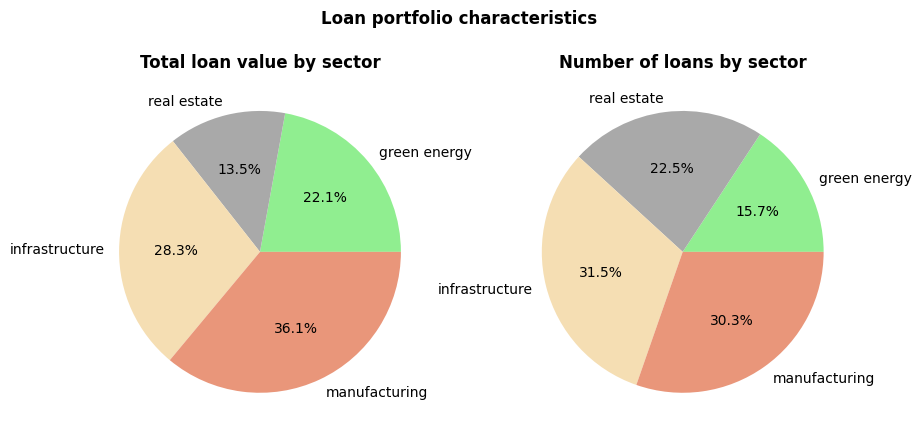

In [25]:
# Loan characteristics for aggregate portfolio
loan_value_by_sector = portfolio_clean.groupby('sector')['loan_size'].sum().reindex(sector_order)
loan_count_by_sector = portfolio_clean.groupby('sector')['loan_size'].count().reindex(sector_order)
colors = [graph_palette[s] for s in sector_order]

fig, axes = plt.subplots(1, 2, figsize=[10, 5])
fig.suptitle('Loan portfolio characteristics', fontweight='bold')

axes[0].pie(loan_value_by_sector, labels=loan_value_by_sector.index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Total loan value by sector', fontweight='bold')

axes[1].pie(loan_count_by_sector, labels=loan_count_by_sector.index, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Number of loans by sector', fontweight='bold')

plt.savefig('images/portfolio_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# Median metrics by sector
median = portfolio_clean.groupby('sector')[['loan_size', 'ebitda_2022', 'leverage_ratio', 'growth_forecast_2023']].median()
median.reindex(sector_order)

,loan_size,ebitda_2022,leverage_ratio,growth_forecast_2023
sector,,,,
green energy,54385000.00,44950000.00,1.43,0.16
real estate,129295000.00,55050000.00,2.55,0.04
infrastructure,204405000.00,60300000.00,4.05,0.01
manufacturing,212980000.00,62100000.00,5.00,-0.06


In [27]:
# Aggregate KPIs by sector
portfolio_clean.groupby('sector').apply(portfolio_kpis, include_groups=False).reindex(sector_order)

,loans,loan_size_bn,leverage_ratio,leverage_2023,growth_forecast_2023
sector,,,,,
green energy,14.00,4.67,0.88,0.76,0.16
real estate,20.00,2.84,2.66,2.55,0.04
infrastructure,28.00,5.97,3.69,3.68,0.00
manufacturing,27.00,7.60,5.49,5.82,-0.06


In [28]:
# Number of loans by leverage level and sector
pd.crosstab(portfolio_clean['sector'], portfolio_clean['leverage_levels']).reindex(sector_order)

leverage_levels,High leverage,Low leverage,Mid-leverage
sector,,,
green energy,0,11,3
real estate,6,5,9
infrastructure,19,4,5
manufacturing,23,0,4


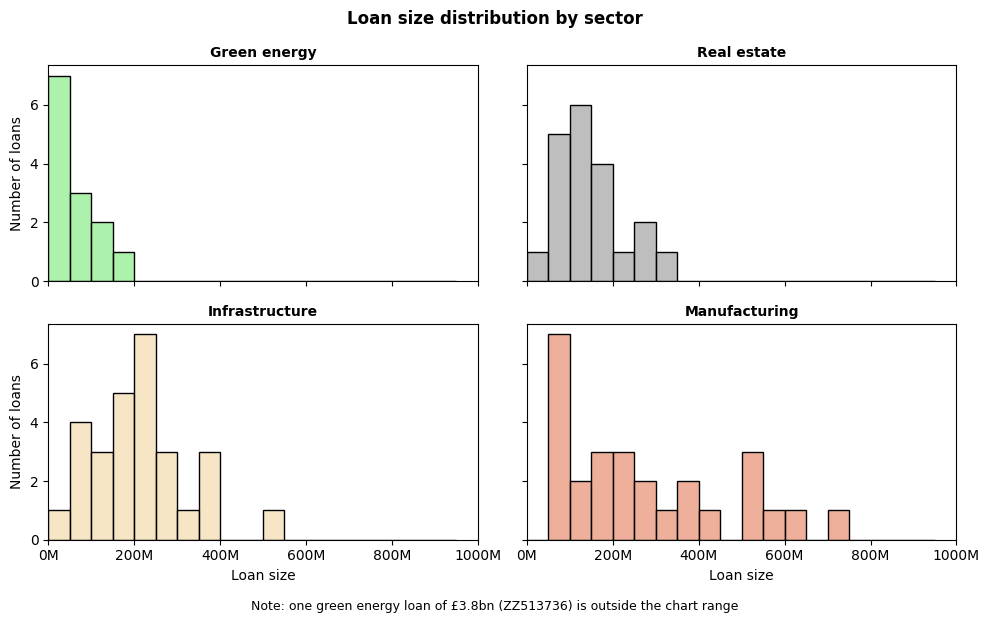

In [29]:
# Loan size distribution by sector
fig, axes = plt.subplots(2, 2, figsize=[10, 6], sharex=True, sharey=True)
fig.suptitle('Loan size distribution by sector', fontweight='bold')

for ax, sector in zip(axes.flatten(), sector_order):
    sns.histplot(portfolio_clean[portfolio_clean['sector'] == sector], x='loan_size',
                 bins=range(0, 1000000000, 50000000), color=graph_palette[sector], ax=ax)
    ax.set_title(sector.capitalize(), fontsize=10, fontweight='bold')
    ax.set_xlim(0, 1000000000)
    ax.xaxis.set_major_formatter(millions_formatter)
    ax.set_xlabel('Loan size')
    ax.set_ylabel('Number of loans')

# The £3.8bn green energy loan (ZZ513736) is not shown to focus on loans below £1bn
fig.text(0.5, -0.02, 'Note: one green energy loan of £3.8bn (ZZ513736) is outside the chart range', ha='center', fontsize=9)
fig.tight_layout()
plt.savefig('images/loan_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Green energy and real estate loans are smaller (median £54m and £129m), infrastructure and manufacturing loans have a median above £200m.

### 2.3 Risk and growth assessment

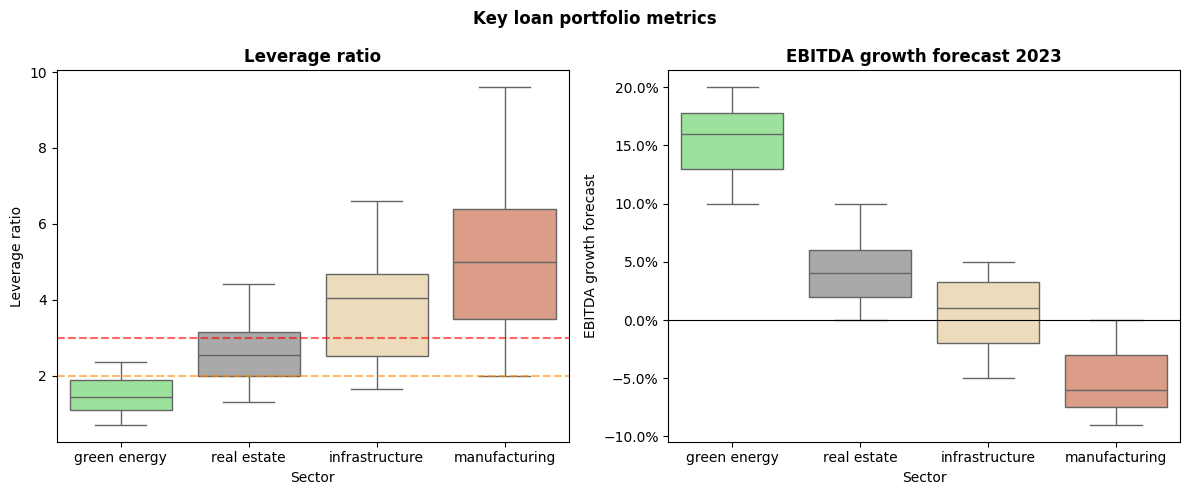

In [30]:
# Boxplot for leverage and EBITDA growth forecast by sector
fig, axes = plt.subplots(1, 2, figsize=[12, 5])
fig.suptitle('Key loan portfolio metrics', fontweight='bold')

sns.boxplot(data=portfolio_clean, x='sector', y='leverage_ratio', hue='sector', order=sector_order, palette=graph_palette, legend=False, ax=axes[0])
axes[0].axhline(3, color='r', linestyle='--', alpha=0.6)
axes[0].axhline(2, color='darkorange', linestyle='--', alpha=0.6)
axes[0].set_xlabel('Sector')
axes[0].set_ylabel('Leverage ratio')
axes[0].set_title('Leverage ratio', fontweight='bold')

sns.boxplot(data=portfolio_clean, x='sector', y='growth_forecast_2023', hue='sector', order=sector_order, palette=graph_palette, legend=False, ax=axes[1])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[1].set_xlabel('Sector')
axes[1].set_ylabel('EBITDA growth forecast')
axes[1].set_title('EBITDA growth forecast 2023', fontweight='bold')

fig.tight_layout()
plt.savefig('images/key_metrics_by_sector.png', dpi=150, bbox_inches='tight')
plt.show()

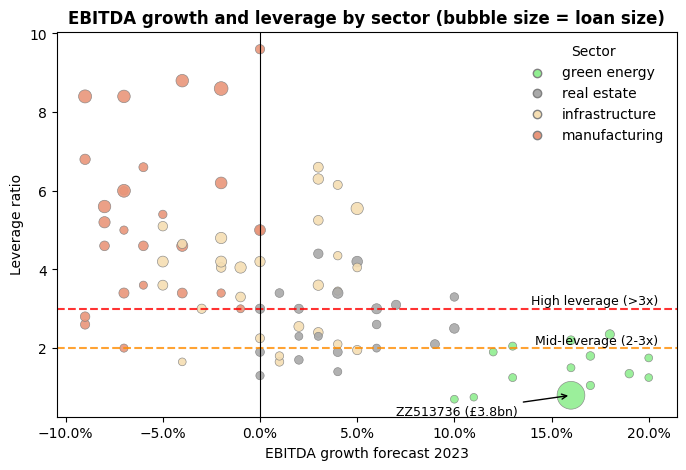

In [31]:
# Leverage vs EBITDA growth by sector (bubble size = loan size)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=portfolio_clean, x='growth_forecast_2023', y='leverage_ratio', hue='sector',
                hue_order=sector_order, palette=graph_palette, size='loan_size', sizes=(30, 400),
                edgecolor='grey', alpha=0.9, legend=False)

plt.axhline(3, color='r', linestyle='--', alpha=0.8)
plt.axhline(2, color='darkorange', linestyle='--', alpha=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.text(0.205, 3.1, 'High leverage (>3x)', fontsize=9, ha='right')
plt.text(0.205, 2.1, 'Mid-leverage (2-3x)', fontsize=9, ha='right')
plt.annotate('ZZ513736 (£3.8bn)', (0.16, 0.8), xytext=(0.07, 0.3), fontsize=9, arrowprops={'arrowstyle': '->'})

# Legend for sectors only
for sector in sector_order:
    plt.scatter([], [], color=graph_palette[sector], edgecolor='grey', label=sector)
plt.legend(title='Sector', loc='upper right', frameon=False)

plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1))
plt.title('EBITDA growth and leverage by sector (bubble size = loan size)', fontweight='bold')
plt.xlabel('EBITDA growth forecast 2023')
plt.ylabel('Leverage ratio')
plt.savefig('images/growth_vs_leverage.png', dpi=150, bbox_inches='tight')
plt.show()

Green energy and real estate are the most attractive sectors: low or mid leverage with positive growth. Manufacturing has no loans below 2x and all growth forecasts are flat or negative. Infrastructure is mostly high leverage with growth around 0%, with only a few loans at 3x or below with positive growth.

### 2.4 Forward leverage (2023)
Leverage above uses 2022 EBITDA. Since we would be holding these loans in 2023, it is also worth looking at leverage based on forecast 2023 EBITDA:

*2023 leverage = loan size / (EBITDA 2022 x (1 + growth forecast 2023))*

Assumption: the loan balance stays the same during 2023 (no repayments).

In [32]:
portfolio_clean['ebitda_2023'] = portfolio_clean['ebitda_2022'] * (1 + portfolio_clean['growth_forecast_2023'])
portfolio_clean['leverage_2023'] = portfolio_clean['loan_size'] / portfolio_clean['ebitda_2023']

leverage_categories_2023 = [
    (portfolio_clean['leverage_2023'] > 3.0),
    (portfolio_clean['leverage_2023'] >= 2.0),
    (portfolio_clean['leverage_2023'] < 2.0)
]
portfolio_clean['leverage_levels_2023'] = np.select(leverage_categories_2023, leverage_levels, default='')

In [33]:
# Median leverage by sector: 2022 vs 2023
portfolio_clean.groupby('sector')[['leverage_ratio', 'leverage_2023']].median().reindex(sector_order)

,leverage_ratio,leverage_2023
sector,,
green energy,1.43,1.21
real estate,2.55,2.36
infrastructure,4.05,3.97
manufacturing,5.00,5.38


In [34]:
# How many loans change leverage level between 2022 and 2023
pd.crosstab(portfolio_clean['leverage_levels'], portfolio_clean['leverage_levels_2023'],
            rownames=['2022'], colnames=['2023'])

2023,High leverage,Low leverage,Mid-leverage
2022,,,
High leverage,46,0,2
Low leverage,0,20,0
Mid-leverage,3,5,13


In [35]:
# Loans that move to a different leverage level
level_change = portfolio_clean[portfolio_clean['leverage_levels'] != portfolio_clean['leverage_levels_2023']]
level_change[['borrower_id', 'sector', 'leverage_ratio', 'leverage_2023', 'growth_forecast_2023', 'leverage_levels', 'leverage_levels_2023']].sort_values('sector')

,borrower_id,sector,leverage_ratio,leverage_2023,growth_forecast_2023,leverage_levels,leverage_levels_2023
47,MJ690532,green energy,2.20,1.90,0.16,Mid-leverage,Low leverage
58,JG687392,green energy,2.35,1.99,0.18,Mid-leverage,Low leverage
63,HN390159,green energy,2.05,1.81,0.13,Mid-leverage,Low leverage
84,DA804130,infrastructure,3.00,3.09,-0.03,Mid-leverage,High leverage
36,NZ188770,manufacturing,3.00,3.03,-0.01,Mid-leverage,High leverage
90,BM647224,manufacturing,2.80,3.08,-0.09,Mid-leverage,High leverage
44,MP369824,real estate,2.00,1.89,0.06,Mid-leverage,Low leverage
66,HJ374750,real estate,3.10,2.90,0.07,High leverage,Mid-leverage
81,DN742019,real estate,3.30,3.00,0.10,High leverage,Mid-leverage
97,AG273655,real estate,2.10,1.93,0.09,Mid-leverage,Low leverage


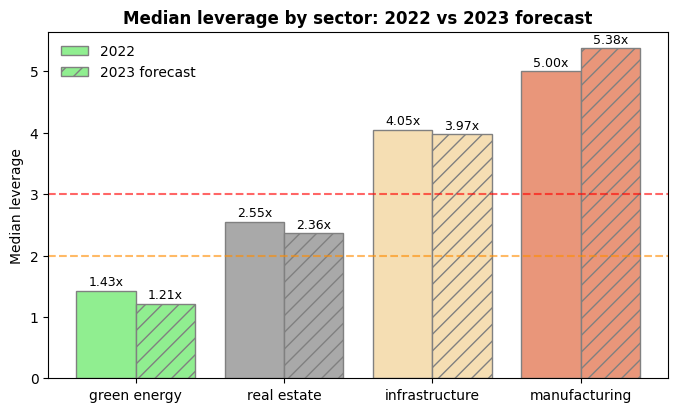

In [36]:
# Median leverage by sector: 2022 vs 2023
median_leverage = portfolio_clean.groupby('sector')[['leverage_ratio', 'leverage_2023']].median().reindex(sector_order)

x = np.arange(len(sector_order))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - 0.2, median_leverage['leverage_ratio'], width=0.4, color=[graph_palette[s] for s in sector_order], edgecolor='grey', label='2022')
ax.bar(x + 0.2, median_leverage['leverage_2023'], width=0.4, color=[graph_palette[s] for s in sector_order], edgecolor='grey', hatch='//', label='2023 forecast')

for i, (v22, v23) in enumerate(zip(median_leverage['leverage_ratio'], median_leverage['leverage_2023'])):
    ax.text(i - 0.2, v22 + 0.08, f'{v22:.2f}x', ha='center', fontsize=9)
    ax.text(i + 0.2, v23 + 0.08, f'{v23:.2f}x', ha='center', fontsize=9)

ax.axhline(3, color='r', linestyle='--', alpha=0.6)
ax.axhline(2, color='darkorange', linestyle='--', alpha=0.6)
ax.set_xticks(x, sector_order)
ax.set_ylabel('Median leverage')
ax.set_title('Median leverage by sector: 2022 vs 2023 forecast', fontweight='bold')
ax.legend(frameon=False)
plt.savefig('images/forward_leverage.png', dpi=150, bbox_inches='tight')
plt.show()

- 10 loans change leverage level in 2023: 5 green energy and real estate loans move from mid to low, 2 real estate loans move from high to mid (HJ374750 and DN742019), and 3 manufacturing and infrastructure loans move from mid to high.
- Sector gaps get wider: green energy and real estate de-lever, while median manufacturing leverage rises from 5.0x to 5.4x.
- Excluding ZZ513736, aggregate leverage barely improves (3.7x in both years), so the portfolio as a whole does not grow out of its debt.

### 2.5 Acquisition options

In [37]:
option1 = portfolio_clean[(portfolio_clean['growth_forecast_2023'] >= 0) & (portfolio_clean['leverage_ratio'] < 2)]
option2 = portfolio_clean[(portfolio_clean['growth_forecast_2023'] >= 0) & (portfolio_clean['leverage_ratio'] <= 3)]

options = pd.DataFrame({
    'Full portfolio': portfolio_kpis(portfolio_clean),
    'Option 1: low leverage, positive growth': portfolio_kpis(option1),
    'Option 2: low and mid leverage, positive growth': portfolio_kpis(option2),
    'Option 2 excl. ZZ513736': portfolio_kpis(option2[option2['borrower_id'] != 'ZZ513736'])
}).T

# Show growth as %
options['growth_forecast_2023'] = (options['growth_forecast_2023'] * 100).round(1).astype(str) + '%'
options

,loans,loan_size_bn,leverage_ratio,leverage_2023,growth_forecast_2023
Full portfolio,89.00,21.08,2.25,2.07,8.8%
"Option 1: low leverage, positive growth",19.00,5.18,0.92,0.80,14.8%
"Option 2: low and mid leverage, positive growth",35.00,7.40,1.13,0.99,13.6%
Option 2 excl. ZZ513736,34.00,3.60,2.00,1.86,7.4%


In [38]:
# Share of ZZ513736 in each option by loan value
for name, df in [('Option 1', option1), ('Option 2', option2)]:
    share = df.loc[df['borrower_id'] == 'ZZ513736', 'loan_size'].sum() / df['loan_size'].sum()
    print(f'{name}: {share:.0%}')

Option 1: 73%
Option 2: 51%


In [39]:
# Sector mix of Option 2
option2.groupby('sector')['loan_size'].agg(['count', 'sum']).reindex(sector_order).fillna(0)

,count,sum
sector,,
green energy,14.00,4666360000.00
real estate,14.00,1677140000.00
infrastructure,7.00,1052520000.00
manufacturing,0.00,0.00


#### Option 2 using 2023 leverage
Using forecast 2023 leverage instead of 2022 leverage for the 3x cut-off adds the 2 real estate loans that move from high to mid leverage.

In [40]:
option2_2023 = portfolio_clean[(portfolio_clean['growth_forecast_2023'] >= 0) & (portfolio_clean['leverage_2023'] <= 3)]
option2_2023_excl = option2_2023[option2_2023['borrower_id'] != 'ZZ513736']

# Loans added compared to Option 2 excl. ZZ513736
option2_excl = option2[option2['borrower_id'] != 'ZZ513736']
print(set(option2_2023_excl['borrower_id']) - set(option2_excl['borrower_id']))

pd.DataFrame({
    'Option 2 excl. ZZ513736': portfolio_kpis(option2_excl),
    'Option 2 (2023 leverage) excl. ZZ513736': portfolio_kpis(option2_2023_excl)
}).T

{'DN742019', 'HJ374750'}


,loans,loan_size_bn,leverage_ratio,leverage_2023,growth_forecast_2023
Option 2 excl. ZZ513736,34.00,3.60,2.00,1.86,0.07
Option 2 (2023 leverage) excl. ZZ513736,36.00,3.86,2.05,1.91,0.07


#### Downside check
What if growth comes in 5 percentage points below forecast for every loan?

In [41]:
stress_ebitda_2023 = option2_excl['ebitda_2022'] * (1 + option2_excl['growth_forecast_2023'] - 0.05)
stress_leverage = option2_excl['loan_size'] / stress_ebitda_2023

print(f"Aggregate 2023 leverage: {option2_excl['loan_size'].sum() / option2_excl['ebitda_2023'].sum():.2f}x forecast, "
      f"{option2_excl['loan_size'].sum() / stress_ebitda_2023.sum():.2f}x with 5pt lower growth")
print(f'Loans above 3x with 5pt lower growth: {(stress_leverage > 3).sum()}')

Aggregate 2023 leverage: 1.86x forecast, 1.95x with 5pt lower growth
Loans above 3x with 5pt lower growth: 2


Option 2 excluding ZZ513736 drops from 2.0x to 1.86x leverage in 2023 and stays below 2x (1.95x) even if growth is 5 points lower than forecast, with only 2 loans moving above 3x. Adding the 2 real estate loans based on 2023 leverage gives 36 loans, £3.9bn and 1.91x forecast leverage.

## 3 Recommendations for the Credit Risk team

1. **Avoid manufacturing**: no loan below 2x leverage and all growth forecasts are flat or negative.
2. **Core purchase: Option 2 excluding ZZ513736**: 34 loans, £3.6bn, 2.0x aggregate leverage (1.86x forecast for 2023) and 7.4% growth. All loans are 3x or below with positive growth, and the mix is spread across green energy, real estate and infrastructure. Leverage stays below 2x even if growth is 5 points lower than forecast.
3. **Consider 2 more real estate loans** (HJ374750, DN742019): currently just above 3x but forecast to be at or below 3x in 2023.
4. **ZZ513736 as a separate decision**: the £3.8bn loan would make up over half of Option 2. Its EBITDA (£4.7bn) is ~100x the sector median, so verify the financials and check the exposure against single-name concentration limits before buying.
5. **Follow up on data quality with the selling bank**: 8 loans had missing, invalid or implausible values (PG964431, DS757939, AD254332, JY724839, BH868720, OK197176, MS704080, CE750358). Some of these could be attractive once corrected.
6. **Next steps**: pricing, interest rate, maturity and collateral data are needed to value the portfolio, not only to screen it for risk.